# Chapter 8: Theoretical Computer Science

Theoretical computer science studied formal computation long before
engineers built a real computer. Alan Turing and others worked out
what machines could and could not do, decades before silicon made
those questions practical. Quantum computers are still catching up
to that tradition: large-scale devices remain out of reach, but the
theoretical analysis of quantum computability and complexity is
already well developed.

This chapter covers three progressively stranger models of
computation (deterministic, probabilistic, quantum) and the
complexity classes each one generates. The punchline: quantum
Turing machines sit in a precise location within the classical
complexity hierarchy, and that location tells us exactly what
quantum speedups can and cannot do.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from math import sqrt, factorial, ceil, floor, log2, comb

## 8.1 Deterministic and Nondeterministic Computations

### Turing Machines

A Turing machine is a device with a two-way infinite tape split into
boxes, each holding one symbol. The machine sits in some state, reads
the current box, and follows a rule: write a new symbol, move left or
right, enter a new state. Formally, a **deterministic Turing machine**
$M$ is a 6-tuple

$$M = (Q,\; \Sigma,\; q_{start},\; q_{accept},\; q_{reject},\; \delta),$$

where $Q$ is a finite set of states, $\Sigma$ is a finite alphabet
(including a blank symbol $\#$), the three $q$-values are distinguished
states, and the **transition function**

$$\delta : Q \times \Sigma \longrightarrow Q \times \Sigma \times \{L, R\}$$

specifies exactly one action for each (state, symbol) pair. Given
state $q$ and symbol $\sigma$, if $\delta(q,\sigma) = (q', \sigma', D)$,
the machine replaces $\sigma$ with $\sigma'$, moves in direction $D$,
and enters state $q'$.

An input string is placed on the tape and the machine runs from
$q_{start}$. Three outcomes are possible: reach $q_{accept}$, reach
$q_{reject}$, or loop forever. Each machine therefore determines a
language $L$ of accepted words.

The **Classical Church-Turing Thesis** asserts that any problem that
is intuitively computable can be solved by a deterministic Turing
machine. This cannot be proved (there is no formal definition of
"intuitively computable"), but most researchers accept it.

### Complexity Classes: P

Computability is not the whole story. We also care about efficiency.
The number of time steps before a machine halts typically depends on
the input size $n$. If every input of size $n$ can be processed in at
most $p(n)$ steps for some polynomial $p$, the problem is tractable.

> **P** is the set of problems solvable by a deterministic Turing
> machine in a **P**olynomial number of steps.

The **Cook-Karp Thesis** refines this: problems that are "tractably
computable" are precisely those in **P**. One might object that
$n^{100}$ is technically polynomial but hardly tractable. True, yet
$n^{100}$ grows slower than any nontrivial exponential (including
$1.001^n$).

### Nondeterministic Turing Machines and NP

A **nondeterministic Turing machine** relaxes the rule that each
(state, symbol) pair has exactly one successor. Instead, the
transition function maps to a *set* of possible actions:

$$\delta : Q \times \Sigma \longrightarrow \wp(Q \times \Sigma \times \{L, R\}).$$

At each step the machine can branch into multiple computational
paths. A word is accepted if *at least one* path reaches
$q_{accept}$.

> **NP** is the set of problems solvable by a **N**ondeterministic
> Turing machine in a **P**olynomial number of steps.

Every deterministic machine is trivially nondeterministic (it just
never branches), so $\mathbf{P} \subseteq \mathbf{NP}$. The
million-dollar question: does $\mathbf{P} = \mathbf{NP}$?

### Complements: coP, coNP

If a problem has a "yes" answer, its **complement** has a "no"
answer, and vice versa.

> **coP** is the set of problems whose complements are in **P**.
>
> **coNP** is the set of problems whose complements are in **NP**.

For deterministic machines, swapping $q_{accept}$ and $q_{reject}$
solves the complement, so $\mathbf{P} = \mathbf{coP}$. This trick
fails for nondeterministic machines: acceptance requires just one
path to succeed, and swapping accept/reject states does not negate
that condition cleanly. Most researchers believe
$\mathbf{NP} \neq \mathbf{coNP}$. Since
$\mathbf{P} \subseteq \mathbf{NP}$, we also have
$\mathbf{P} = \mathbf{coP} \subseteq \mathbf{coNP}$.

### PSPACE

Time is not the only resource. We can also bound the amount of tape
used.

> **PSPACE** is the set of problems solvable by a deterministic (or
> equivalently, nondeterministic) Turing machine using a
> **P**olynomial number of **SPACE**s on the tape.

Savitch's theorem shows that deterministic and nondeterministic
polynomial space coincide (up to a polynomial blowup). A machine
that runs in $p(n)$ time can touch at most $p(n)$ tape cells, so
$\mathbf{NP} \subseteq \mathbf{PSPACE}$ and
$\mathbf{coNP} \subseteq \mathbf{PSPACE}$.

Summary of deterministic/nondeterministic inclusions:

$$\mathbf{P} \subseteq \mathbf{NP} \subseteq \mathbf{PSPACE}$$
$$\mathbf{P} = \mathbf{coP} \subseteq \mathbf{coNP} \subseteq \mathbf{PSPACE}$$

Whether any of these inclusions is strict remains open.

### Exercise 8.1.1

**Problem.** Write a deterministic Turing machine that determines
if the input string has a substring "101." You might begin by
moving off the center a little. For an input of size $n$, how many
moves does the Turing machine make in the worst case?

**Solution.** The machine scans left-to-right looking for the pattern
1-0-1. It needs three states tracking how much of "101" has been
matched so far (0, 1, or 2 characters). On a mismatch the machine
resets appropriately (similar to KMP pattern matching). In the worst
case the entire string of length $n$ is scanned once, so the machine
uses $O(n)$ steps. More precisely, the machine makes at most
$n + \frac{n}{2}$ moves if it starts at center (needs to reach one
end, reverse, and scan the full string).

### Exercise 8.1.2

**Problem.** Find the least $n$ such that $1.001^n \geq n^{100}$.

**Solution (from Appendix B).** $n = 1{,}417{,}122$.

The exponential $1.001^n$ eventually overtakes *any* polynomial,
but "eventually" can mean a very large $n$. Let us verify
computationally.

In [2]:
# Exercise 8.1.2: find least n where 1.001^n >= n^100
# We use logarithms to avoid overflow: n*log(1.001) >= 100*log(n)
import math

# Start at n=2 because log(1)=0 makes the comparison degenerate
n = 2
while n * math.log(1.001) < 100 * math.log(n):
    # Jump in bigger steps for speed, then refine
    if n < 1_000_000:
        n += 1000
    else:
        n += 1

# Refine: back up and step by 1
n = max(2, n - 1001)
while n * math.log(1.001) < 100 * math.log(n):
    n += 1

print(f"Least n where 1.001^n >= n^100: {n:,}")
print(f"Check: n*ln(1.001) = {n * math.log(1.001):.4f}")
print(f"       100*ln(n)   = {100 * math.log(n):.4f}")

Least n where 1.001^n >= n^100: 1,417,122
Check: n*ln(1.001) = 1416.4139
       100*ln(n)   = 1416.4139


### Exercise 8.1.3

**Problem.** Show that every nondeterministic Turing machine is
equivalent to one that bifurcates into exactly two states at every
time step.

**Solution (from Appendix B).** The idea is to replace any branching
node with a cascade of binary splits.

If at some point the machine can enter $k > 2$ successor
configurations, replace the $k$-way branch with a binary tree of
depth $\lceil \log_2 k \rceil$. Each internal node splits into exactly
two children. If $k$ is not a power of 2, some leaves duplicate an
existing branch.

Special cases:
- $k = 2$: no change needed.
- $k = 1$ (deterministic step): duplicate the single successor into
  both branches (the machine splits into two identical copies).
- $k = 0$: split into two copies of itself (both halt or loop
  identically).

The resulting machine takes at most $O(\log k)$ extra steps per
original step, preserving polynomial time.

## 8.2 Probabilistic Computations

### Probabilistic Turing Machines

A **probabilistic Turing machine** is like a nondeterministic one,
except the transitions carry probabilities instead of mere
possibilities. Formally, the transition function assigns to each
(state, symbol) pair a probability distribution over possible
actions:

$$\delta : Q \times \Sigma \longrightarrow \widetilde{[0,1]}^{Q \times \Sigma \times \{L,R\}}$$

where $\widetilde{[0,1]}$ denotes tractably computable real numbers
in $[0,1]$. For every state and symbol, the probabilities of all
possible moves must sum to 1.

At each step, a random number determines which action the machine
performs. Running the same program on the same input can produce
different results. This means the machine can err: accepting an
input it should reject (false positive) or rejecting one it should
accept (false negative).

### Complexity Classes for Probabilistic Machines

The complexity classes are defined by which types of errors are
permitted. In each case the machine must halt in polynomial time.

> **BPP** (Bounded-error Probabilistic Polynomial time): both false
> positives and false negatives allowed. If $x \in L$ then
> $\Pr(\text{accept}) > 2/3$; if $x \notin L$ then
> $\Pr(\text{reject}) > 2/3$.

> **RP** (Randomized Polynomial time): only false negatives. If
> $x \in L$ then $\Pr(\text{accept}) > 2/3$; if $x \notin L$ then
> $\Pr(\text{reject}) = 1$.

> **coRP**: only false positives. If $x \in L$ then
> $\Pr(\text{accept}) = 1$; if $x \notin L$ then
> $\Pr(\text{reject}) > 2/3$.

> **ZPP** (Zero-error Probabilistic Polynomial time): no errors, but
> the machine may output "don't know" with probability $< 1/2$.
> When it does give an answer, the answer is always correct.

These classes satisfy
$\mathbf{ZPP} = \mathbf{RP} \cap \mathbf{coRP}$ and the inclusion
chain:

$$\mathbf{P} \subseteq \mathbf{ZPP} \subseteq \mathbf{RP} \subseteq \mathbf{BPP}$$
$$\mathbf{P} \subseteq \mathbf{ZPP} \subseteq \mathbf{coRP} \subseteq \mathbf{BPP}$$

### The Amplification Lemma

The fraction $2/3$ in these definitions looks arbitrary, and it is.
Any fraction greater than $1/2$ yields the same complexity classes.
The reason: the **amplification lemma**.

Run the algorithm $k$ times and take a majority vote. If each run
is correct with probability $p > 1/2$, the majority is correct with
probability that grows exponentially in $k$. Specifically, the error
probability after $k$ independent runs drops as
$O(e^{-\Omega(k)})$.

Since $k$ polynomial-time runs still take polynomial time, we can
drive the error probability below any desired threshold while staying
in the same complexity class.

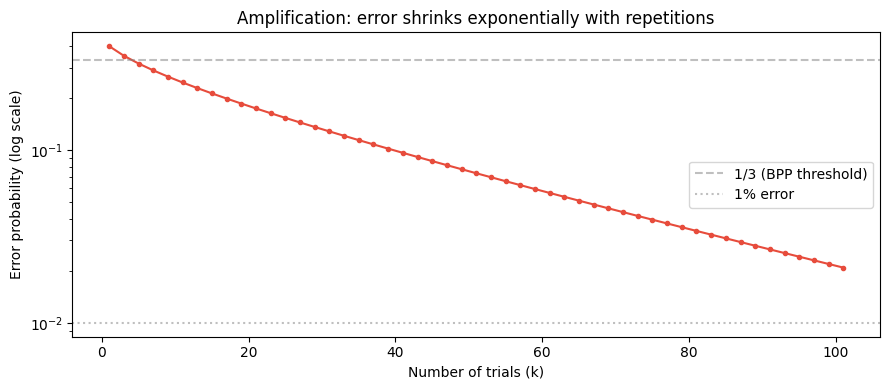

Single trial error: 40.0%
After 11 trials:   24.6502%
After 51 trials:   7.35292020%
After 101 trials:  2.09e-02


In [3]:
# Amplification Lemma demonstration
# A probabilistic algorithm with per-trial accuracy p = 0.6
# (barely better than a coin flip). Run it k times, take majority vote.

def binomial_cdf(k_max, n, p):
    """P(X <= k_max) for X ~ Binomial(n, p), using math.comb."""
    return sum(comb(n, i) * p**i * (1-p)**(n-i) for i in range(k_max + 1))

p_single = 0.6  # probability of correct answer per trial

trials = list(range(1, 102, 2))  # odd numbers only (clean majority)
error_probs = []

for k in trials:
    majority = k // 2 + 1
    # Probability that majority is correct = P(at least majority successes)
    p_correct = 1 - binomial_cdf(majority - 1, k, p_single)
    error_probs.append(1 - p_correct)

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(trials, error_probs, 'o-', markersize=3, color='#e74c3c')
ax.set_xlabel('Number of trials (k)')
ax.set_ylabel('Error probability (log scale)')
ax.set_title('Amplification: error shrinks exponentially with repetitions')
ax.axhline(1/3, color='gray', linestyle='--', alpha=0.5, label='1/3 (BPP threshold)')
ax.axhline(0.01, color='gray', linestyle=':', alpha=0.5, label='1% error')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Single trial error: {1-p_single:.1%}")
print(f"After 11 trials:   {error_probs[5]:.4%}")
print(f"After 51 trials:   {error_probs[25]:.8%}")
print(f"After 101 trials:  {error_probs[50]:.2e}")

### Relating Probabilistic and Deterministic Classes

A deterministic Turing machine is a probabilistic machine that never
guesses, so $\mathbf{P} \subseteq \mathbf{ZPP}$.

An **RP** computation has at least $2/3$ of its paths ending in
$q_{accept}$ when $x \in L$, which is more than one path, so
$\mathbf{RP} \subseteq \mathbf{NP}$. Similarly
$\mathbf{coRP} \subseteq \mathbf{coNP}$.

A **BPP** machine can traverse all paths using polynomial space
(keeping a tally of accept/reject counts), so
$\mathbf{BPP} \subseteq \mathbf{PSPACE}$. By similar analysis,
$\mathbf{NP} \subseteq \mathbf{PSPACE}$ and
$\mathbf{coNP} \subseteq \mathbf{PSPACE}$.

The relationship between **BPP** and **NP** is unknown.

### The Strong Church-Turing Thesis

> The **Strong Church-Turing Thesis** states that any efficient
> computation that can be performed by *any* physical machine can
> be simulated by a probabilistic Turing machine in polynomial time
> (i.e., in **BPP**).

If a quantum computer can efficiently solve problems outside **BPP**,
this thesis falls. That is one of the deepest stakes of quantum
computing.

### Exercise 8.2.1

**Problem.** Following Example 8.1.1 (searching an odd-length string
for a "1"), describe a probabilistic Turing machine that solves the
same problem. Since we are dealing with probabilistic algorithms,
we permit false negatives.

**Solution (from Appendix B).** The probabilistic version of
Example 8.1.1 starts at the center of the string. At the first step,
it moves left with probability $1/2$ and right with probability
$1/2$. Once committed to a direction, it scans deterministically.
If it finds a "1," it accepts. If it reaches the end of the word
without finding a "1," it rejects.

This machine examines $n/2 + 1$ symbols and gives the correct answer
more than half the time. It can produce false negatives (the "1"
might be in the half it didn't scan) but never false positives.

Following Exercise 8.1.3, every probabilistic Turing machine can be
made to split into exactly two configurations. The probability $r$
is represented as a binary string: if the next binary digit is "0,"
take one branch; if "1," take the other.

### Exercise 8.2.2

**Problem.** Describe a probabilistic Turing machine that does not
generate any false negatives for the "contains a 1" problem. The
machine should start by randomly moving left or right. If it hits
an end without finding a "1," it should reverse direction. Make
sure the machine does not loop forever. Show worst-case time is
$3n/2$.

**Solution.** Start at the center and randomly pick left or right.
Scan in that direction. If a "1" is found, accept immediately. If
the end of the string is reached without finding "1," reverse
direction and scan the other half.

This never generates false negatives: both halves are always
checked if needed. False positives are impossible (the machine only
accepts when it actually sees a "1").

Worst case: the machine goes all the way to one end ($n/2$ steps),
reverses, and scans the entire string ($n$ steps) before finding
"1" at the far end (or rejecting). Total: $3n/2$ steps.

### Exercise 8.2.3

**Problem.** Describe a probabilistic Turing machine that determines
whether the input string contains the substring "101." Give one
version that permits false negatives and one that does not.

**Solution.** The approach mirrors Exercises 8.2.1 and 8.2.2:

*With false negatives:* Start at the center and randomly pick a
direction. Scan that half of the string using a finite-state pattern
matcher for "101." Accept if found, reject if you reach the end.
This may miss "101" in the unscanned half.

*Without false negatives:* Same as above, but on reaching an end
without finding "101," reverse and scan the remaining half.
Worst case: $3n/2$ steps, same as Exercise 8.2.2. Note: when the
pattern straddles the center point, the reversal scan will catch it
because the scanner restarts its state machine from the center.

## 8.3 Quantum Computations

### Quantum Turing Machines

A **quantum Turing machine** follows the same template as its
probabilistic cousin, with one change: the transition amplitudes are
complex numbers instead of probabilities. Formally:

$$M = (Q,\; \Sigma,\; q_{start},\; q_{accept},\; q_{reject},\; \delta')$$

where the transition function maps to tractably computable complex
numbers $\tilde{\mathbb{C}}$:

$$\delta' : Q \times \Sigma \times Q \times \Sigma \times \{L, R\} \longrightarrow \tilde{\mathbb{C}}$$

The key constraint: for any state $q$ and symbol $\sigma$, the
squared norms of the amplitudes must sum to 1:

$$\sum_{q', \sigma', D} |\delta'(q, \sigma, q', \sigma', D)|^2 = 1.$$

A probabilistic machine randomly picks one branch. A quantum machine
takes *all* branches simultaneously, entering a superposition of
configurations. The complex amplitudes allow constructive and
destructive interference between paths. This is the essential
difference.

### Configuration Space and $U_M$

For a given quantum Turing machine, the set of all possible
configurations forms a countably infinite complex vector space
$\mathfrak{C}$. A state of the machine is a vector in this space:

$$|\psi\rangle = \sum_j c_j |\text{Config}_j\rangle$$

One time step applies a (countably infinite) matrix $U_M$ to this
vector. The machine is **well formed** when $U_M$ is an isometry
(preserves inner products). After $t(n)$ steps from initial
configuration $|\text{Config}_I\rangle$, the state is
$U_M^{t(n)}|\text{Config}_I\rangle$.

Observing the machine collapses the superposition to a single
classical configuration, with probability given by the squared
norm of the corresponding amplitude. Before observation, the
amplitudes (complex numbers) add up as a sum, allowing interference.
After observation, the result is a single classical outcome.

### Yao's Theorem

A quantum Turing machine is just one model of quantum computation.
Quantum circuits (Chapters 5 and 6) are another. In the classical
world, logical circuits and Turing machines are polynomially
equivalent. Yao (1993) proved the same holds for the quantum case:

> **Yao's Theorem.** Quantum circuits and quantum Turing machines
> are polynomially equivalent. Any computation in one model can be
> simulated by the other with at most polynomial overhead.

This means complexity results proved for one model transfer to the
other.

### Quantum Complexity Classes

The quantum complexity classes mirror their probabilistic
counterparts, replacing "probabilistic Turing machine" with
"quantum Turing machine."

> **BQP** (Bounded-error Quantum Polynomial time): If $x \in L$,
> $\Pr(\text{accept}) > 2/3$; if $x \notin L$,
> $\Pr(\text{reject}) > 2/3$.

> **ZQP**: quantum analog of ZPP. Zero error, but may output
> "don't know."

> **EQP** (Exact Quantum Polynomial time): no error whatsoever.
> $\Pr(\text{correct}) = 1$.

The amplification lemma works for quantum machines too (proven by
Bennett et al., 1997), so the fraction $2/3$ in BQP is not
significant.

Containment:

$$\mathbf{EQP} \subseteq \mathbf{ZQP} \subseteq \mathbf{BQP}$$

### Where BQP Sits

The key relationships between quantum and classical classes:

- $\mathbf{P} \subseteq \mathbf{EQP}$: a deterministic machine is a
  trivial quantum machine.
- $\mathbf{BPP} \subseteq \mathbf{BQP}$: a quantum machine can
  simulate a probabilistic one (use Hadamard to generate fair coin
  flips).
- $\mathbf{BQP} \subseteq \mathbf{PSPACE}$: a classical machine
  using polynomial space can track all quantum amplitudes. The
  simulation takes exponential *time* but only polynomial *space*.

Combining everything:

$$\mathbf{P} \subseteq \mathbf{BPP} \subseteq \mathbf{BQP} \subseteq \mathbf{PSPACE}$$

It is strongly believed that $\mathbf{BPP} \subsetneq \mathbf{BQP}$
(because of Shor's algorithm and the belief that no polynomial-time
probabilistic algorithm can factor integers). If
$\mathbf{BPP} \neq \mathbf{BQP}$ were proved, we would also know
$\mathbf{P} \neq \mathbf{PSPACE}$, an open problem for decades.

### Shor, Grover, and What They Mean

**Shor's algorithm** factors integers in polynomial time on a quantum
computer. Since no polynomial-time classical algorithm is known for
factoring, this is evidence (not proof) that $\mathbf{BPP} \neq
\mathbf{BQP}$.

Factoring is an **NP** problem (and a **coNP** problem) but is
*not* believed to be NP-complete. A large-scale quantum computer
running Shor's algorithm would break RSA cryptography but would
*not* solve arbitrary NP-complete problems like SAT or Hamiltonian
path.

**Grover's algorithm** searches an unstructured space of size $N$ in
$O(\sqrt{N})$ steps instead of the classical $O(N)$. The speedup is
quadratic, not exponential. For an NP problem with search space
$2^n$, Grover reduces the work to $O(2^{n/2})$: still exponential,
but the square root of the classical effort. Bennett (1997) showed
this is optimal: no quantum algorithm can search an unstructured
space faster than $O(\sqrt{N})$.

The Deutsch-Jozsa and Simon algorithms (Chapter 6) also demonstrate
exponential speedups over classical algorithms, for their specific
problems.

### Code Demo: Classical vs. Grover Step Counts

The textbook (Table 8.59) compares a classical brute-force search
against Grover's algorithm. The classical computer performs 100,000
function evaluations per second; the quantum computer performs 1,000
per second (100x slower). Even with this handicap, the quantum
computer wins for large $n$ because $\sqrt{2^n}$ grows so much
slower than $2^n$.

In [4]:
# Classical (2^n ops at 100,000/sec) vs Grover (sqrt(2^n) ops at 1,000/sec)
# Reproduce Table 8.59 from the textbook

classical_rate = 100_000  # ops/sec
quantum_rate = 1_000     # ops/sec

def format_time(seconds):
    if seconds < 1:
        return f"{seconds:.6f} sec"
    elif seconds < 60:
        return f"{seconds:.2f} sec"
    elif seconds < 86400:
        return f"{seconds/86400:.5f} days"
    elif seconds < 365.25 * 86400:
        return f"{seconds/86400:.2f} days"
    else:
        return f"{seconds/(365.25*86400):.2f} years"

ns = [5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 100, 125]

print(f"{'n':>4}  {'Classical ops':>15}  {'Classical time':>18}  "
      f"{'Grover ops':>15}  {'Grover time':>18}")
print('-' * 80)

for n in ns:
    c_ops = 2**n
    g_ops = 2**(n/2)
    c_time = c_ops / classical_rate
    g_time = g_ops / quantum_rate
    print(f"{n:>4}  {c_ops:>15.6g}  {format_time(c_time):>18}  "
          f"{g_ops:>15.6g}  {format_time(g_time):>18}")

   n    Classical ops      Classical time       Grover ops         Grover time
--------------------------------------------------------------------------------
   5               32        0.000320 sec          5.65685        0.005657 sec
  10             1024        0.010240 sec               32        0.032000 sec
  15            32768        0.327680 sec          181.019        0.181019 sec
  20      1.04858e+06           10.49 sec             1024            1.02 sec
  25      3.35544e+07        0.00388 days          5792.62            5.79 sec
  30      1.07374e+09        0.12428 days            32768           32.77 sec
  40      1.09951e+12         127.26 days      1.04858e+06        0.01214 days
  50       1.1259e+15        356.78 years      3.35544e+07        0.38836 days
  60      1.15292e+18     365338.78 years      1.07374e+09          12.43 days
  70      1.18059e+21  374106909.50 years      3.43597e+10          1.09 years
 100      1.26765e+30  401694235375386432.00 years

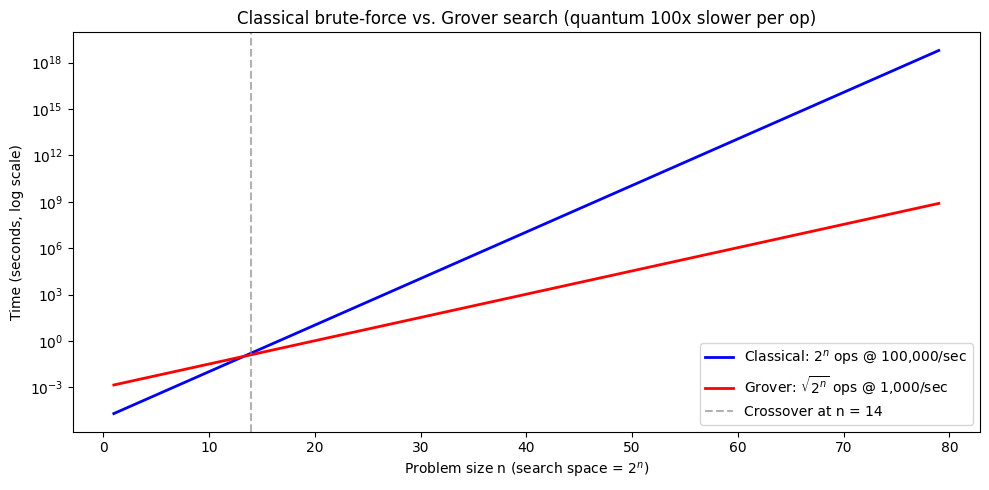


Grover becomes faster at n = 14
Despite the quantum computer being 100x slower per operation.


In [5]:
# Visualization: crossover point where quantum beats classical
n_range = np.arange(1, 80)
classical_time = 2.0**n_range / classical_rate
grover_time = 2.0**(n_range / 2) / quantum_rate

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(n_range, classical_time, 'b-', linewidth=2,
            label=f'Classical: $2^n$ ops @ {classical_rate:,}/sec')
ax.semilogy(n_range, grover_time, 'r-', linewidth=2,
            label=f'Grover: $\\sqrt{{2^n}}$ ops @ {quantum_rate:,}/sec')

# Find crossover
cross_idx = np.argmax(grover_time < classical_time)
ax.axvline(n_range[cross_idx], color='gray', linestyle='--', alpha=0.6,
           label=f'Crossover at n = {n_range[cross_idx]}')

ax.set_xlabel('Problem size n (search space = $2^n$)')
ax.set_ylabel('Time (seconds, log scale)')
ax.set_title('Classical brute-force vs. Grover search (quantum 100x slower per op)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nGrover becomes faster at n = {n_range[cross_idx]}")
print(f"Despite the quantum computer being 100x slower per operation.")

### Exercise 8.3.1

**Problem.** Do a similar analysis to Example 8.3.1 (which shows
the configuration-space vector and matrix $U_M$ for a deterministic
Turing machine) for a reversible deterministic Turing machine and
for a probabilistic Turing machine.

**Solution (from Appendix B).**

For a **reversible** deterministic Turing machine: every row of
$U_M$ has exactly one entry equal to 1, all others 0. This means
$U_M$ is a permutation matrix (and therefore unitary). Each
configuration maps to exactly one successor, and the mapping is
invertible.

For a **probabilistic** Turing machine: every column of $U_M$ sums
to 1 (the probabilities of transitioning into all possible successor
configurations sum to 1). This makes $U_M$ a (left) stochastic
matrix. The entries are non-negative real numbers rather than just
0s and 1s.

### Exercise 8.3.2

**Problem.** Write a quantum Turing machine that determines if
there is a substring "101" on the tape.

**Solution.** Following the approach of Example 8.3.2 (the quantum
version of the "contains a 1" problem), construct a quantum Turing
machine that:

1. From $q_{start}$, enters a superposition of moving left and
   right with equal amplitude $1/\sqrt{2}$ each.
2. In each branch, uses a deterministic finite automaton (tracking
   match progress for "101") as the state transitions.
3. On finding the pattern, transitions to $q_{accept}$.
4. On reaching the end marker $\#$ without a match, enters
   $q_{reject}$.

The quantum version scans both halves simultaneously in
superposition. If "101" exists in either half, the corresponding
branch reaches $q_{accept}$ and measurement will detect it with
high probability. The running time is $n/2$ steps.

### Exercise 8.3.3

**Problem.** Write a program to determine the exact $n$ where the
slower quantum computer running Grover's algorithm first beats the
classical brute-force search (search space $2^n$, quantum computer
100x slower per operation).

**Solution (from Appendix B).** From the table in the text, the
crossover is between $n = 10$ and $n = 15$. A closer analysis
gives:

In [6]:
# Exercise 8.3.3: exact crossover n for 2^n search space
# Classical: 2^n / 100,000   Quantum: sqrt(2^n) / 1,000

print(f"{'n':>4}  {'Classical (sec)':>16}  {'Grover (sec)':>16}  {'Winner':>10}")
print('-' * 55)

for n in range(10, 20):
    c_time = 2**n / 100_000
    g_time = 2**(n/2) / 1_000
    winner = 'GROVER' if g_time < c_time else 'Classical'
    print(f"{n:>4}  {c_time:>16.6f}  {g_time:>16.6f}  {winner:>10}")

# Find exact crossover: 2^n / 100,000 = sqrt(2^n) / 1,000
# => 2^n / sqrt(2^n) = 100,000 / 1,000 = 100
# => sqrt(2^n) = 100 => 2^n = 10,000 => n = log2(10,000)
import math
n_exact = math.log2(10_000)
print(f"\nExact crossover: n = log2(10000) = {n_exact:.4f}")
print(f"First integer n where Grover wins: n = {math.ceil(n_exact)}")

   n   Classical (sec)      Grover (sec)      Winner
-------------------------------------------------------
  10          0.010240          0.032000   Classical
  11          0.020480          0.045255   Classical
  12          0.040960          0.064000   Classical
  13          0.081920          0.090510   Classical
  14          0.163840          0.128000      GROVER
  15          0.327680          0.181019      GROVER
  16          0.655360          0.256000      GROVER
  17          1.310720          0.362039      GROVER
  18          2.621440          0.512000      GROVER
  19          5.242880          0.724077      GROVER

Exact crossover: n = log2(10000) = 13.2877
First integer n where Grover wins: n = 14


### Exercise 8.3.4

**Problem.** Perform a similar analysis to Table 8.59 for an NP
problem whose search space is $n!$.

**Solution (from Appendix B).** With search space $n!$ instead of
$2^n$, the classical machine performs $n!$ operations and Grover
performs $\sqrt{n!}$. The speedup is even more dramatic because
$n!$ grows faster than $2^n$.

In [7]:
# Exercise 8.3.4: n! search space comparison
# Classical: n! / 100,000   Quantum: sqrt(n!) / 1,000

ns_factorial = [5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 100, 125]

print(f"{'n':>4}  {'n! ops':>15}  {'Classical time':>18}  "
      f"{'sqrt(n!) ops':>15}  {'Grover time':>18}")
print('-' * 80)

for n in ns_factorial:
    nfact = float(factorial(n))
    c_ops = nfact
    g_ops = sqrt(nfact)
    c_time = c_ops / classical_rate
    g_time = g_ops / quantum_rate
    print(f"{n:>4}  {c_ops:>15.5g}  {format_time(c_time):>18}  "
          f"{g_ops:>15.5g}  {format_time(g_time):>18}")

   n           n! ops      Classical time     sqrt(n!) ops         Grover time
--------------------------------------------------------------------------------
   5              120        0.001200 sec           10.954        0.010954 sec
  10       3.6288e+06           36.29 sec           1904.9            1.90 sec
  15       1.3077e+12         151.35 days       1.1435e+06        0.01324 days
  20       2.4329e+18     770940.12 years       1.5598e+09          18.05 days
  25       1.5511e+25  4915205859549.20 years       3.9384e+12        124.80 years
  30       2.6525e+32  84053559146510204928.00 years       1.6287e+16     516090.74 years
  40       8.1592e+47  258547951443676856211418176949321728.00 years       9.0328e+23  28623225166784.62 years
  50       3.0414e+64  9637644561599543169436641950071742682143699924680704.00 years        1.744e+32  5526287426368311394304.00 years
  60        8.321e+81  2636761703279523580303304300378343370850733250189445152630358713303040.00 years   

### Complexity Class Containment Diagram

The full picture, combining all three sections. Lines indicate
inclusion (lower is contained in higher). Whether any inclusion
is strict remains an open problem.

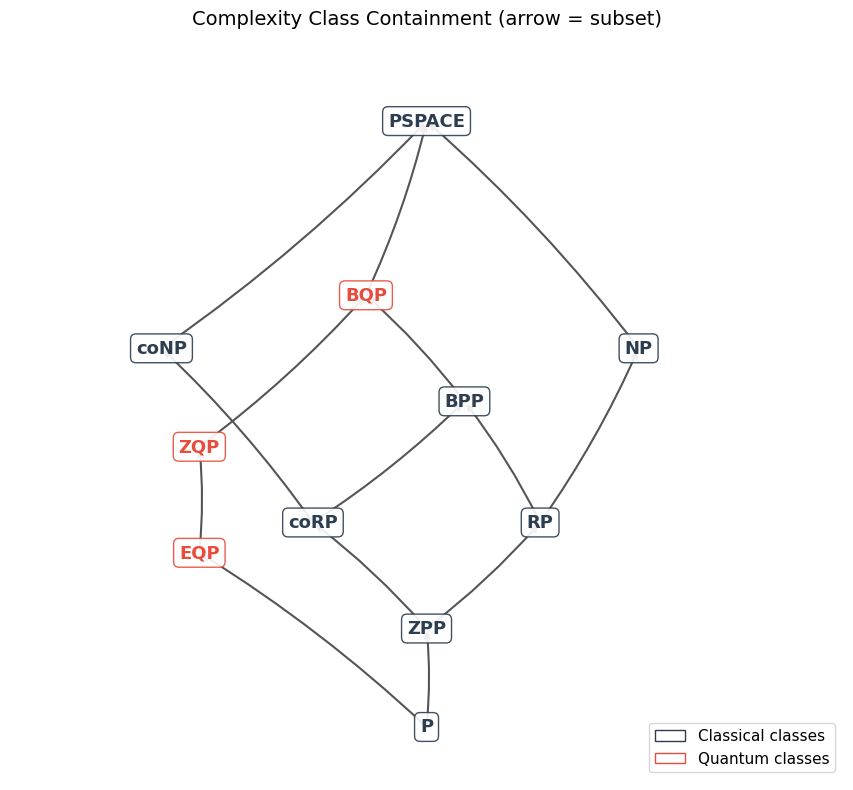

In [8]:
# Complexity class Hasse diagram
# Positions: (x, y) for each class
positions = {
    'P':      (0.50, 0.05),
    'ZPP':    (0.50, 0.18),
    'RP':     (0.65, 0.32),
    'coRP':   (0.35, 0.32),
    'EQP':    (0.20, 0.28),
    'ZQP':    (0.20, 0.42),
    'BPP':    (0.55, 0.48),
    'NP':     (0.78, 0.55),
    'coNP':   (0.15, 0.55),
    'BQP':    (0.42, 0.62),
    'PSPACE': (0.50, 0.85),
}

# Edges: (child, parent)
edges = [
    ('P', 'ZPP'),
    ('ZPP', 'RP'),
    ('ZPP', 'coRP'),
    ('RP', 'BPP'),
    ('coRP', 'BPP'),
    ('RP', 'NP'),
    ('coRP', 'coNP'),
    ('P', 'EQP'),
    ('EQP', 'ZQP'),
    ('ZQP', 'BQP'),
    ('BPP', 'BQP'),
    ('BQP', 'PSPACE'),
    ('NP', 'PSPACE'),
    ('coNP', 'PSPACE'),
]

fig, ax = plt.subplots(figsize=(9, 8))

# Draw edges
for child, parent in edges:
    cx, cy = positions[child]
    px, py = positions[parent]
    ax.annotate('', xy=(px, py), xytext=(cx, cy),
                arrowprops=dict(arrowstyle='->', color='#555555',
                                lw=1.5, connectionstyle='arc3,rad=0.05'))

# Draw nodes
classical_classes = {'P', 'ZPP', 'RP', 'coRP', 'BPP', 'NP', 'coNP', 'PSPACE'}
quantum_classes = {'EQP', 'ZQP', 'BQP'}

for name, (x, y) in positions.items():
    if name in quantum_classes:
        color = '#e74c3c'
        fontweight = 'bold'
    else:
        color = '#2c3e50'
        fontweight = 'bold'
    ax.text(x, y, name, ha='center', va='center', fontsize=13,
            fontweight=fontweight, color=color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=color, alpha=0.9))

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.02, 0.95)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Complexity Class Containment (arrow = subset)', fontsize=14, pad=15)

# Legend
classical_patch = mpatches.Patch(edgecolor='#2c3e50', facecolor='white',
                                 label='Classical classes')
quantum_patch = mpatches.Patch(edgecolor='#e74c3c', facecolor='white',
                               label='Quantum classes')
ax.legend(handles=[classical_patch, quantum_patch], loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

### Running Example: Three Models, One Problem

Examples 8.1.1, 8.2.1, and 8.3.2 from the textbook all solve the
same problem (does a string contain a "1"?) with three different
types of Turing machine. The running times summarize the chapter's
core message:

| Model | Exact answer | Probabilistic answer |
|-------|-------------|---------------------|
| **Deterministic** | $n + n/2$ | N/A |
| **Probabilistic** | $n + n/2$ | $n/2$ |
| **Quantum** | $n/2$ | N/A |

The quantum machine matches the probabilistic machine's speed while
giving an exact answer. It achieves this through superposition:
instead of randomly picking one half of the string, it scans both
halves simultaneously. This is the Turing-machine version of the
double-slit experiment.

### The Strong Church-Turing Thesis Revisited

The Strong Church-Turing Thesis claimed that a probabilistic Turing
machine can efficiently simulate any physical device. Quantum
computing challenges this directly.

Shor's algorithm is the strongest evidence. If factoring truly
requires super-polynomial time classically (as most researchers
believe), then a quantum computer performs an efficient computation
that no probabilistic machine can match. Building a large-scale
quantum computer would settle the question empirically.

Even Grover's more modest quadratic speedup matters. For an NP
problem with search space $2^n$, the quantum approach needs only
$O(2^{n/2})$ evaluations. Classically, $2^n$ evaluations are
required (and Bennett showed $O(2^{n/2})$ is optimal for quantum
search of unstructured spaces). The following code lets you feel
this difference.

### Code Demo: Amplification in Practice

To make amplification concrete, here is a simulated probabilistic
algorithm that is right only 60% of the time. We run it $k$ times
and take a majority vote. The plot shows how quickly the error
vanishes.

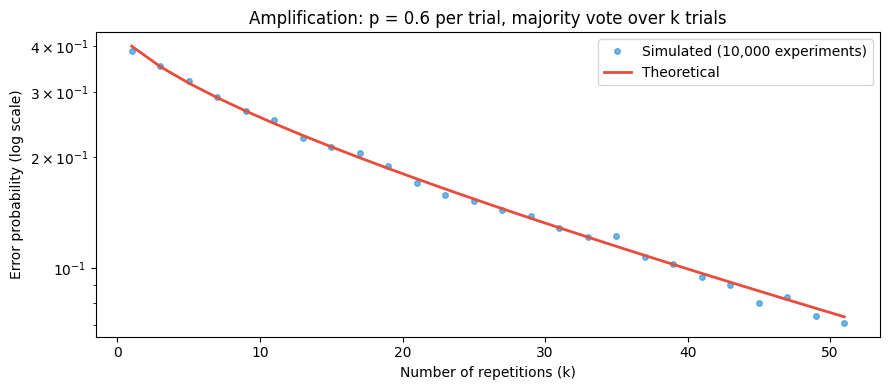

k=1:  error = 0.389
k=11: error = 0.2521
k=51: error = 0.070800


In [9]:
# Simulate amplification with a noisy oracle
np.random.seed(42)

p_correct = 0.6
num_experiments = 10_000
k_values = list(range(1, 52, 2))  # odd k only

measured_errors = []
theoretical_errors = []

for k in k_values:
    # Simulate: each experiment runs k trials
    trials = np.random.random((num_experiments, k)) < p_correct
    majority_correct = trials.sum(axis=1) > k / 2
    measured_error = 1 - majority_correct.mean()
    measured_errors.append(measured_error)
    
    # Theoretical: P(fewer than k/2 correct)
    theo_error = sum(comb(k, i) * p_correct**i * (1-p_correct)**(k-i)
                     for i in range(k // 2 + 1))
    theoretical_errors.append(theo_error)

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(k_values, measured_errors, 'o', markersize=4, color='#3498db',
            label='Simulated (10,000 experiments)', alpha=0.7)
ax.semilogy(k_values, theoretical_errors, '-', color='#e74c3c', linewidth=2,
            label='Theoretical')
ax.set_xlabel('Number of repetitions (k)')
ax.set_ylabel('Error probability (log scale)')
ax.set_title(f'Amplification: p = {p_correct} per trial, majority vote over k trials')
ax.legend()
plt.tight_layout()
plt.show()

print(f"k=1:  error = {measured_errors[0]:.3f}")
print(f"k=11: error = {measured_errors[5]:.4f}")
print(f"k=51: error = {measured_errors[25]:.6f}")

## Summary

Three models of computation, three families of complexity classes:

1. **Deterministic** Turing machines give us **P** and **PSPACE**.
   Nondeterministic machines add **NP** and **coNP**.

2. **Probabilistic** Turing machines add **BPP**, **RP**, **coRP**,
   and **ZPP**. The amplification lemma shows that even a tiny edge
   over random guessing can be boosted to near-certainty.

3. **Quantum** Turing machines add **BQP**, **ZQP**, and **EQP**.
   Complex amplitudes enable interference, which is the source of
   quantum speedups.

The established containment $\mathbf{P} \subseteq \mathbf{BQP}
\subseteq \mathbf{PSPACE}$ pins down quantum computing's location
in the complexity landscape. Shor's factoring algorithm provides an
exponential speedup for a specific problem. Grover's search
algorithm gives a quadratic speedup for any unstructured search, and
that quadratic bound is provably optimal.

The big open question: is the inclusion
$\mathbf{BPP} \subseteq \mathbf{BQP}$ strict? If yes, quantum
computers are fundamentally more powerful than classical ones, and
the Strong Church-Turing Thesis is false.